In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.linear_model import Lasso



# Exercises

There are three exercises in this notebook:

1. Use the cross-validation method to test the linear regression with different $\alpha$ values, at least three.
2. Implement a SGD method that will train the Lasso regression for 10 epochs.
3. Extend the Fisher's classifier to work with two features. Use the class as the $y$.

## 1. Cross-validation linear regression

You need to change the variable ``alpha`` to be a list of alphas. Next do a loop and finally compare the results.

In [50]:
x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)

x = np.asmatrix(np.c_[np.ones((15,1)),x])

I = np.identity(2)
alphas = [0.01, 0.05, 0.1, 0.5, 1.0]

for alpha in alphas:
    w = np.linalg.inv(x.T*x + alpha * I)*x.T*y
    w = w.ravel()
    print(f"alpha={alpha}, w={w}")



alpha=0.01, w=[[-167.85534019    1.54416013]]
alpha=0.05, w=[[-130.22804017    1.33115036]]
alpha=0.1, w=[[-101.72397081    1.16978757]]
alpha=0.5, w=[[-36.97522016   0.80324169]]
alpha=1.0, w=[[-20.59044706   0.71048616]]


## 2. Implement based on the Ridge regression example, the Lasso regression.

Please implement the SGD method and compare the results with the sklearn Lasso regression results. 

In [ ]:
def sgd(X, y, alpha=0.1, lr=0.05, epochs=10, seed=0):
    X = X.astype(float).copy()
    y = np.asarray(y, dtype=float).ravel()
    n, m = X.shape

    mean = X[:, 1:].mean(axis=0)
    std = X[:, 1:].std(axis=0)
    std[std == 0] = 1.0
    X[:, 1:] = (X[:, 1:] - mean) / std

    w = np.zeros(m, dtype=float)
    rng = np.random.default_rng(seed)

    for _ in range(epochs):
        for i in rng.permutation(n):
            xi = X[i]
            error = xi @ w - y[i]

            grad = error * xi
            grad[1:] += alpha * np.sign(w[1:])
            w -= lr * grad

    w_out = w.copy()
    w_out[1:] = w[1:] / std
    w_out[0] = w[0] - np.sum(mean * w[1:] / std)

    return w_out

In [46]:
x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(15,1)

x = np.c_[np.ones((15,1)), x]
y = y.ravel()

alpha = 0.01

w_sgd = sgd(x, y, alpha=alpha, lr=0.05, epochs=10)
print("SGD Lasso (10 epochs):", w_sgd)

model = Lasso(alpha=alpha, fit_intercept=False, max_iter=10000)
model.fit(x, y)
print("sklearn Lasso:", model.coef_)

SGD Lasso (10 epochs): [-178.80565683    1.60651413]
sklearn Lasso: [-179.65019317    1.61093097]


## 3. Extend the Fisher's classifier

Write numpy code that performs Fisher classification using all the features of Iris data. Choose species nr 1 and 2 as two classes. Plot original data and their projection. Using obtained model classify the flower with the folowing features: [6.45, 2.85, 4.25, 1.25].

Fisher direction w: [-0.22684996 -0.35584988  0.44461153  0.79008262]
Threshold: 1.0629073520310501
Training accuracy: 0.97
Flower class: 1 -> versicolor


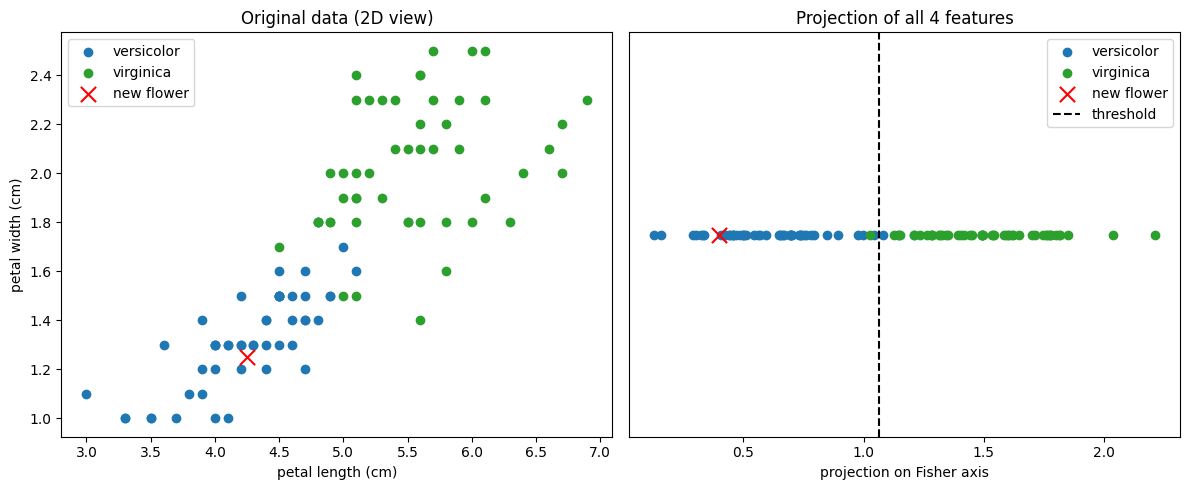

In [48]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

mask = (y == 1) | (y == 2)
X = X[mask]
y = y[mask]

X1 = X[y == 1]
X2 = X[y == 2]

mu1 = X1.mean(axis=0)
mu2 = X2.mean(axis=0)

S1 = (X1 - mu1).T @ (X1 - mu1)
S2 = (X2 - mu2).T @ (X2 - mu2)
Sw = S1 + S2

w = np.linalg.pinv(Sw) @ (mu2 - mu1)
w = w / np.linalg.norm(w)

proj1 = X1 @ w
proj2 = X2 @ w

if proj1.mean() > proj2.mean():
    w = -w
    proj1 = X1 @ w
    proj2 = X2 @ w

threshold = 0.5 * (proj1.mean() + proj2.mean())

y_pred = np.where(X @ w >= threshold, 2, 1)
accuracy = np.mean(y_pred == y)

flower = np.array([6.45, 2.85, 4.25, 1.25])
flower_proj = flower @ w
flower_class = 2 if flower_proj >= threshold else 1

print("Fisher direction w:", w)
print("Threshold:", threshold)
print("Training accuracy:", accuracy)
print("Flower class:", flower_class, "->", iris.target_names[flower_class])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X1[:, 2], X1[:, 3], color="tab:blue", label=iris.target_names[1])
axes[0].scatter(X2[:, 2], X2[:, 3], color="tab:green", label=iris.target_names[2])
axes[0].scatter(flower[2], flower[3], color="red", marker="x", s=120, label="new flower")
axes[0].set_xlabel("petal length (cm)")
axes[0].set_ylabel("petal width (cm)")
axes[0].set_title("Original data (2D view)")
axes[0].legend()

axes[1].scatter(proj1, np.zeros_like(proj1), color="tab:blue", label=iris.target_names[1])
axes[1].scatter(proj2, np.zeros_like(proj2), color="tab:green", label=iris.target_names[2])
axes[1].scatter(flower_proj, 0, color="red", marker="x", s=120, label="new flower")
axes[1].axvline(threshold, color="black", linestyle="--", label="threshold")
axes[1].set_yticks([])
axes[1].set_xlabel("projection on Fisher axis")
axes[1].set_title("Projection of all 4 features")
axes[1].legend()

plt.tight_layout()
plt.show()